In [4]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt

In [1]:
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue  = "#1B3F6B"

palette = [winter_pine, cranberry, golden, oxford_blue]

In [3]:
# Load data
import pickle

with open('TPS_data/tps_standard.pkl', 'rb') as f:
    standard_list = pickle.load(f)

with open('TPS_data/tps_standard1000K.pkl', 'rb') as f:
    standard_1000 = pickle.load(f)

tps_ensemble = standard_list['tps ensemble']
naive_tps_ensemble = standard_list['naive tps ensemble']
auto_correlation = standard_list['autocorrelation']
transit_times = standard_list['transit times']
mean_time = standard_list['mean time']
std_time = standard_list['std time']
mean_hops = standard_list['mean hops']
std_hops = standard_list['std hops']
q_hops = standard_list['q hops']
MC_rate = standard_list['MC rate']

tps1000_ensemble = standard_1000

ModuleNotFoundError: No module named 'trajectory'

In [7]:
# Verification

traj_with_hop = 0
burn_in = 0.15
discard = int(burn_in * len(tps_ensemble))
trimmed_tps_ensemble = tps_ensemble[discard:]
for k in range(0, len(trimmed_tps_ensemble)):
    traj = trimmed_tps_ensemble[k]
    # --- Positions ---
    oscillator_positions = np.array([traj[i].positions for i in range(len(traj))])
    active_states = np.array([traj[i].active_state for i in range(len(traj))])
    if np.any(active_states) == 1:
        traj_with_hop +=1
print(traj_with_hop)

2719


In [8]:
transit_1000 = []
dt = 5
for traj in tps1000_ensemble:
    grid_snaps = [s for s in traj if s.is_grid]
    transit_1000.append((len(grid_snaps) - 1) * dt)
meantime_1000 = np.mean(transit_1000)

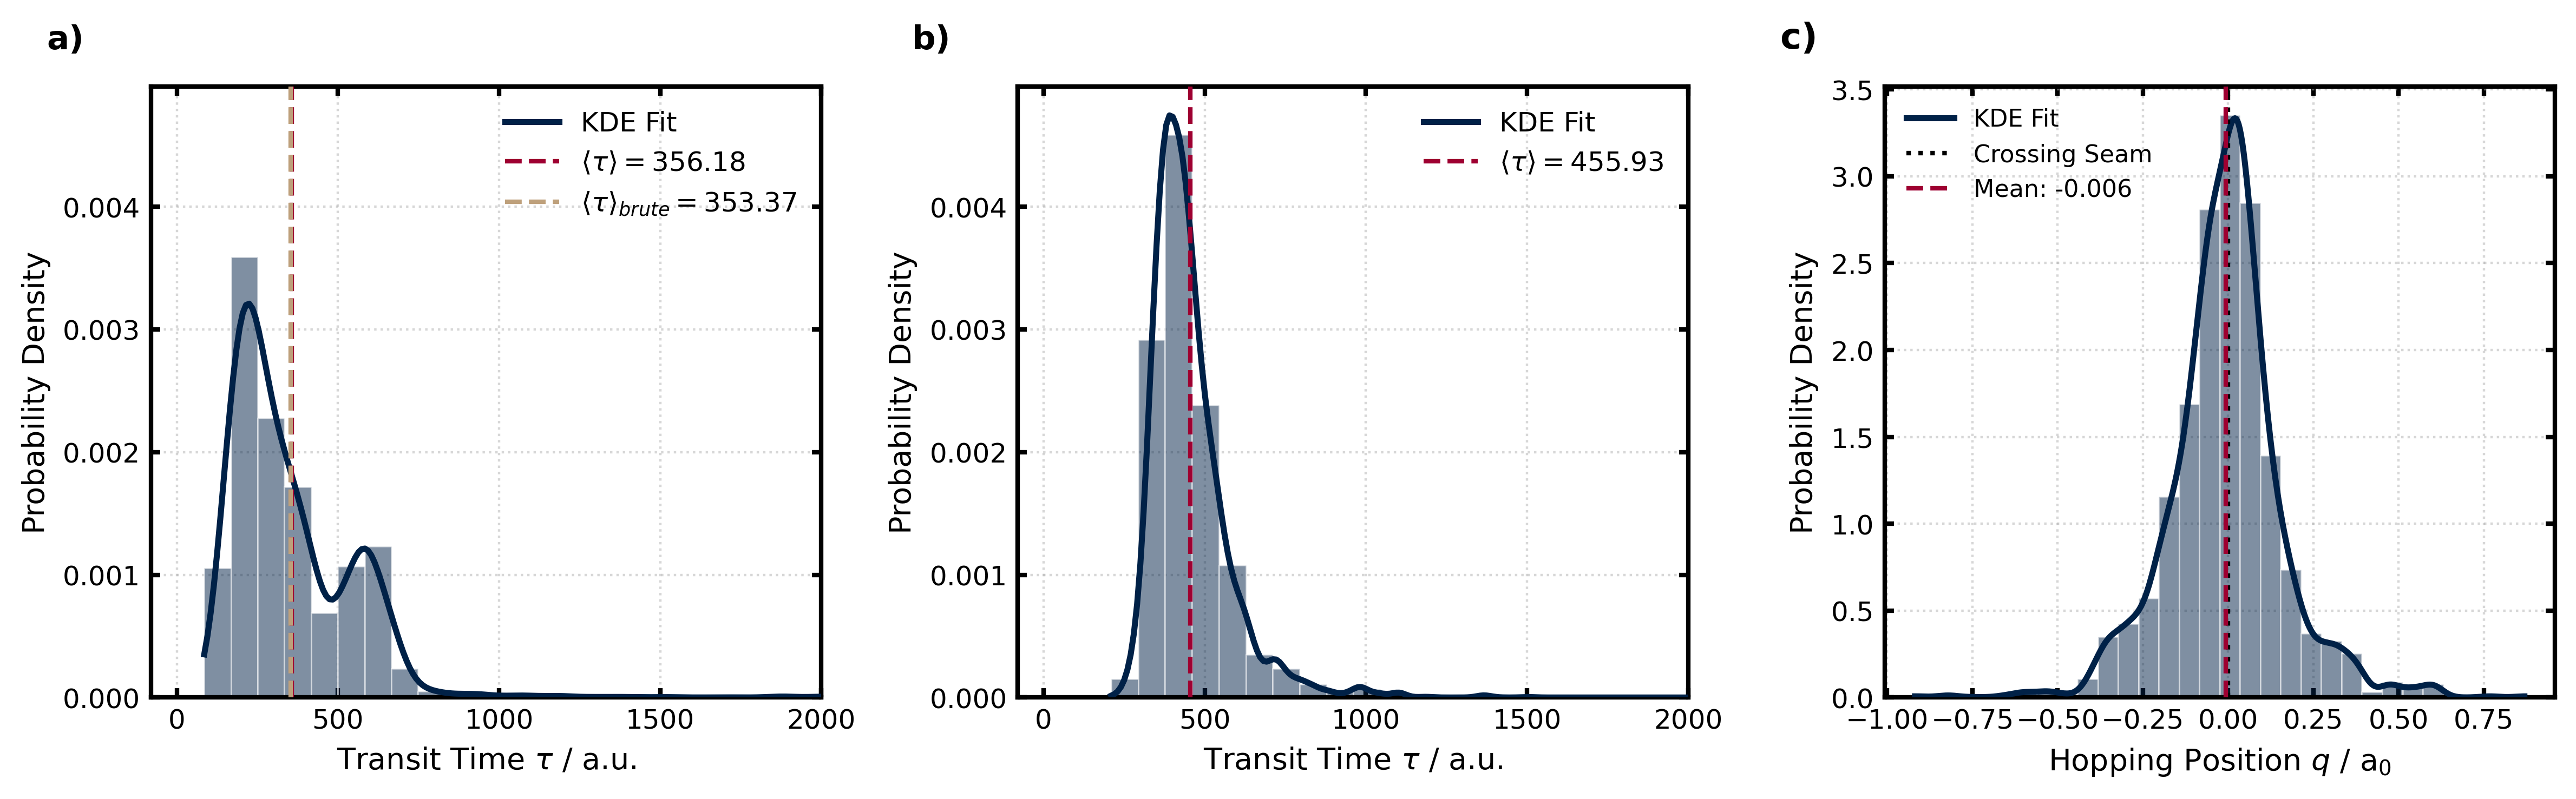

In [11]:
# Plot the two transition time distribution curves: 12000K and 1000K

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def plot_transit_time_dists_publish(transit_times_a, mean_a, transit_times_b, mean_b):
    # Colors (Replace with your exact hex codes if different)
    oxford_blue = '#002147'
    cranberry = '#9E0031'

    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Double-column width (approx 7.0 x 2.8) for side-by-side
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12.0, 3.8), dpi=400)
    
    datasets = [
        (transit_times_a, mean_a, 'a)'),
        (transit_times_b, mean_b, 'b)')
    ]

    # ==========================================
    # 2. PLOTTING LOOP
    # ==========================================
    for i, (transit_times, mean_time, panel_label) in enumerate(datasets):
        ax = axs[i]
        
        # The elegant, modern histogram
        ax.hist(
            transit_times,
            bins=60,
            density=True,
            color=oxford_blue,
            edgecolor='white',
            linewidth=0.5,
            alpha=0.5,
            zorder=2
        )

        # The smooth KDE curve
        kde = gaussian_kde(transit_times)
        x_grid = np.linspace(min(transit_times), max(transit_times), 500)
        ax.plot(x_grid, kde(x_grid), color=oxford_blue, linewidth=2, zorder=3, label="KDE Fit")

        # The Mean Marker
        ax.axvline(mean_time, color=cranberry, linestyle='--', linewidth=1.5, zorder=4,
                   label=rf'$\langle \tau \rangle = {mean_time:.2f}$')
        if i == 0:
            ax.axvline(353.37, color=golden, linestyle='--', linewidth=1.5, zorder=4,
                   label=r'$\langle \tau \rangle_{brute} = 353.37$')

        # ==========================================
        # 3. LABELS & FORMATTING
        # ==========================================
        ax.set_xlabel(r"Transit Time $\tau$ / a.u.", fontweight='medium')

        ax.set_ylabel("Probability Density", fontweight='medium')
        
        ax.set_xlim([-80, 2000])

        # Grid and Ticks
        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

        # Thicken axes
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

        # Panel Label (a) and (b)
        ax.text(-0.1, 1.05, panel_label, transform=ax.transAxes, 
                fontsize=11, fontweight='bold', va='bottom', ha='right')

        # Clean, borderless legend
        ax.legend(loc='upper right', frameon=False, fontsize=9)

    y_max = max(axs[0].get_ylim()[1], axs[1].get_ylim()[1])
    axs[0].set_ylim(0, y_max)
    axs[1].set_ylim(0, y_max)
    
    # Optional: remove y-axis numbers from panel (b) for a cleaner look
    # axs[1].set_yticklabels([])

        # ==========================================
    # 2. PLOTTING THE DISTRIBUTION
    # ==========================================
    # The elegant, modern histogram in Winter Pine
    ax3 = axs[2]
    ax3.hist(
        q_hops,
        bins=30,
        density=True,
        color=oxford_blue,
        edgecolor='white',    # Sharp white borders
        linewidth=0.5,
        alpha=0.5,            # Soft transparency
        zorder=2
    )

    # The smooth KDE envelope
    kde = gaussian_kde(q_hops)
    x_grid = np.linspace(min(q_hops), max(q_hops), 500)
    ax3.plot(x_grid, kde(x_grid), color=oxford_blue, linewidth=2, zorder=3, label="KDE Fit")

    # The Theoretical Crossing Seam (Black dotted)
    ax3.axvline(0.0, color='black', linestyle=':', linewidth=1.5, zorder=4,
               label='Crossing Seam')

    # The Calculated Mean Marker (Cranberry for high contrast)
    mean_q = np.mean(q_hops)
    ax3.axvline(mean_q, color=cranberry, linestyle='--', linewidth=1.5, zorder=5,
               label=rf'Mean: {mean_q:.3f}')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Journal-standard unit formatting
    ax3.set_xlabel(r"Hopping Position $q$ / a$_0$", fontweight='medium')
    ax3.set_ylabel("Probability Density", fontweight='medium')

    # Grid and Ticks
    ax3.tick_params(direction='in', top=True, right=True)
    ax3.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax3.spines.values():
        spine.set_linewidth(1.5)

    # Clean, borderless legend with slightly smaller font to fit the markers
    ax3.legend(loc='upper left', frameon=False, fontsize=8)
    ax3.text(-0.1, 1.05, 'c)', transform=ax3.transAxes, fontsize=12, fontweight='bold', va='bottom', ha='right')

    plt.tight_layout()
    plt.savefig("Transit_Time_Distributions_Combined.png", dpi=400, bbox_inches='tight')
    plt.show()

# Example usage:
plot_transit_time_dists_publish(transit_times, mean_time, transit_1000, meantime_1000)

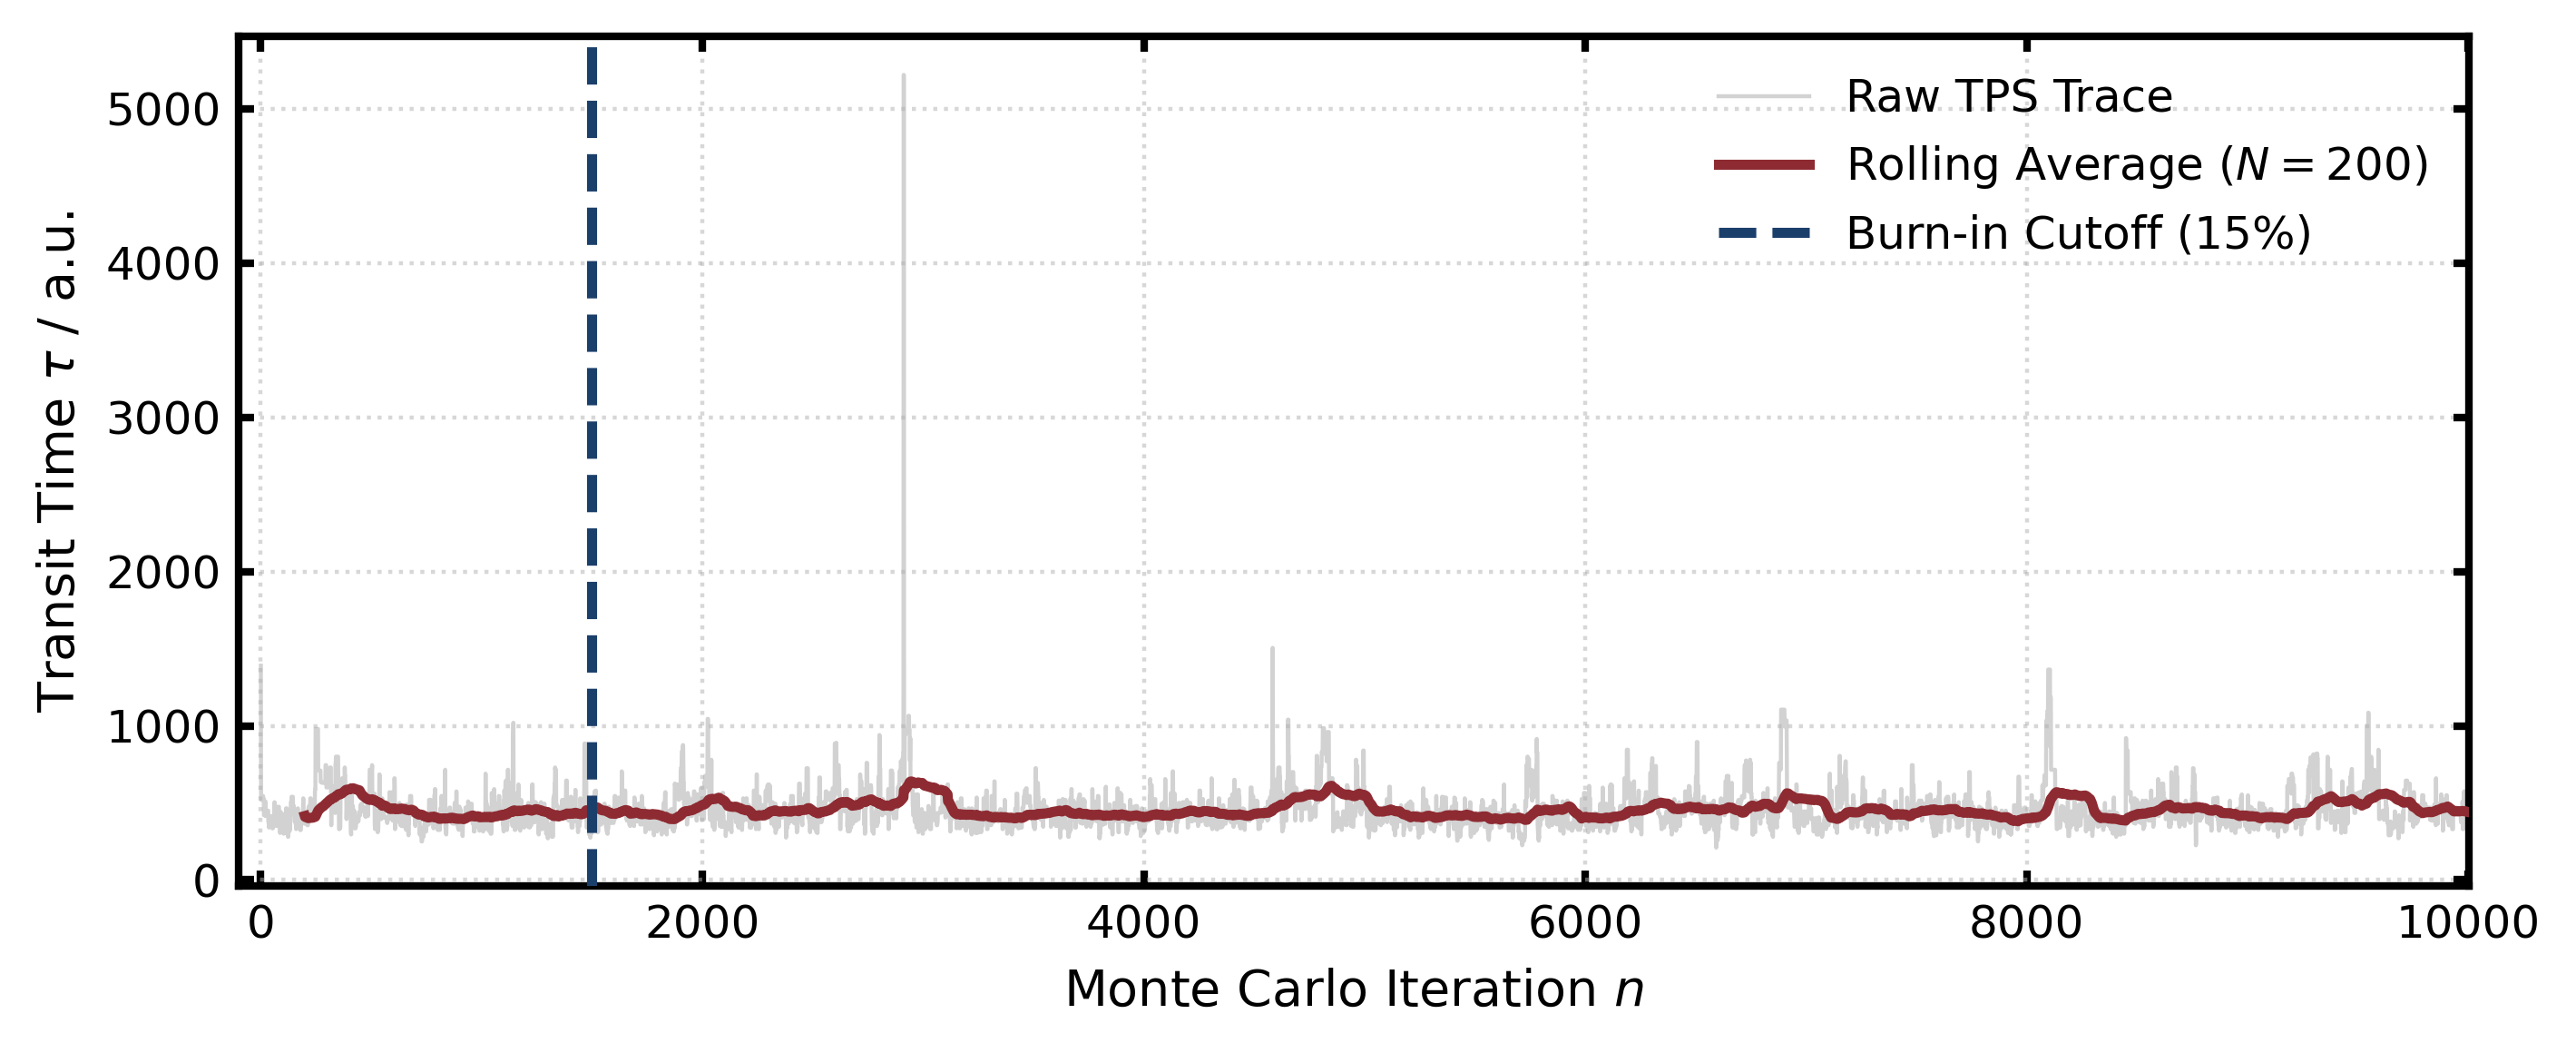

In [10]:
def verify_equilibration_publish(tps_ensemble, dt, temp, burn_in_fraction=0.15, window_size=200):
    """
    Plots a highly polished MCMC trace of transit times to visually 
    verify the burn-in period and chain equilibration.
    """
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Double-column width, relatively short to emphasize the horizontal time evolution
    fig, ax = plt.subplots(figsize=(7.2, 3.0), dpi=400)

    # ==========================================
    # 2. DATA PROCESSING (Untouched)
    # ==========================================
    transit_times = []
    for traj in tps_ensemble:
        grid_snaps = [s for s in traj if s.is_grid]
        transit_times.append((len(grid_snaps) - 1) * dt)
        
    transit_times = np.array(transit_times)
    iterations = np.arange(len(transit_times))
    
    kernel = np.ones(window_size) / window_size
    rolling_mean = np.convolve(transit_times, kernel, mode='valid')
    rolling_iters = iterations[window_size - 1:]

    # ==========================================
    # 3. PLOTTING
    # ==========================================
    # Raw trace (faint gray so it provides texture without overwhelming the plot)
    ax.plot(iterations, transit_times, color='gray', alpha=0.35, linewidth=0.8, 
            zorder=1, label='Raw TPS Trace')
    
    # Smoothed trace (Bold Cranberry)
    ax.plot(rolling_iters, rolling_mean, color=cranberry, linewidth=2.0, 
            zorder=3, label=f'Rolling Average ($N={window_size}$)')
    
    # Burn-in Cutoff (Oxford Blue)
    assumed_burn_in = int(len(tps_ensemble) * burn_in_fraction)
    ax.axvline(x=assumed_burn_in, color=oxford_blue, linestyle='--', linewidth=2.0, 
               zorder=4, label=f'Burn-in Cutoff ({int(burn_in_fraction*100)}%)')

    # ==========================================
    # 4. LABELS & FORMATTING
    # ==========================================
    ax.set_xlabel("Monte Carlo Iteration $n$", fontweight='medium')
    ax.set_ylabel(r"Transit Time $\tau$ / a.u.", fontweight='medium')
    
    # Tight bounds to eliminate floating white space on the x-axis
    ax.set_xlim(-100, len(iterations))
    
    # Inward ticks and clean grid
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Minimalist legend, placed in the top right to usually avoid the bulk of the data
    ax.legend(loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(f"MCMC_Equilibration_T{temp}K.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:

verify_equilibration_publish(tps_ensemble=tps1000_ensemble, dt=dt, temp=1000)

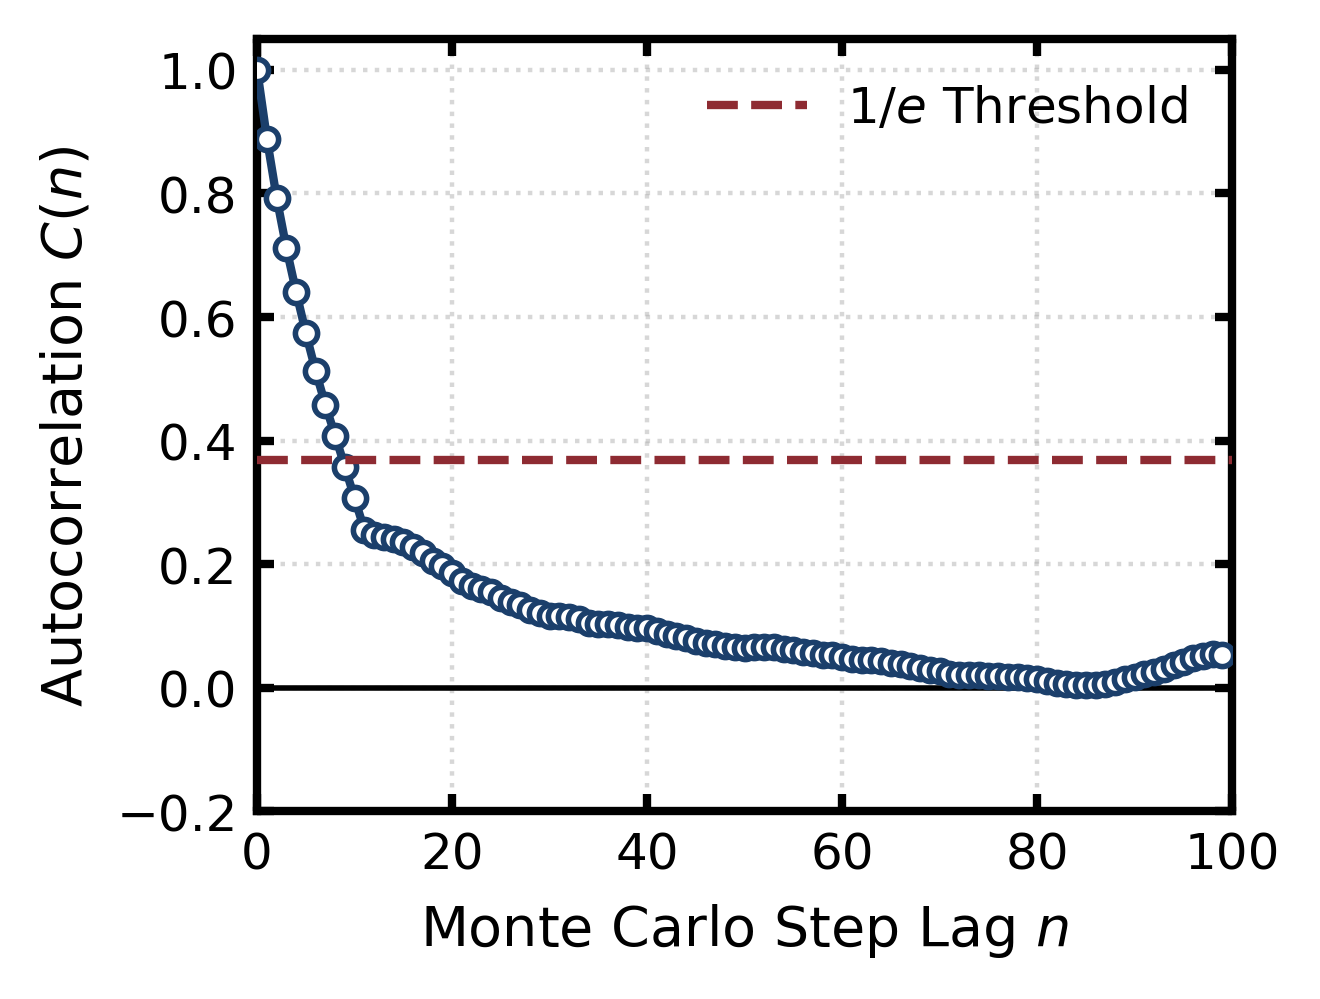

In [6]:
def plot_autocorrelation_publish(auto_correlation, max_mc_lag):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Standard single-column width (3.4 x 2.6)
    fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=400)

    # ==========================================
    # 2. PLOTTING THE AUTOCORRELATION
    # ==========================================
    # Main decay line (Winter Pine)
    # Adding white marker faces for that crisp, premium journal look
    ax.plot(range(max_mc_lag), auto_correlation, color=oxford_blue, 
            linewidth=1.5, linestyle='-', marker='o', markersize=4, 
            markerfacecolor='white', markeredgewidth=1.0, zorder=3)
    
    # y=0 baseline
    ax.axhline(0, color='black', linewidth=1.0, zorder=2)
    
    # 1/e Threshold (Cranberry)
    ax.axhline(np.exp(-1), color=cranberry, linestyle='--', linewidth=1.5, zorder=4, 
               label=r'$1/e$ Threshold')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    ax.set_xlabel("Monte Carlo Step Lag $n$", fontweight='medium')
    ax.set_ylabel(r"Autocorrelation $C(n)$", fontweight='medium')

    # Grid and Ticks
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Frame the data perfectly
    ax.set_xlim(0, max_mc_lag)
    # Standard limits for normalized ACF to show the peak at 1.0 and a bit of negative space
    ax.set_ylim(-0.2, 1.05) 

    # Clean, borderless legend
    ax.legend(loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig("TPS_Autocorrelation.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_autocorrelation_publish(auto_correlation, max_mc_lag=100)

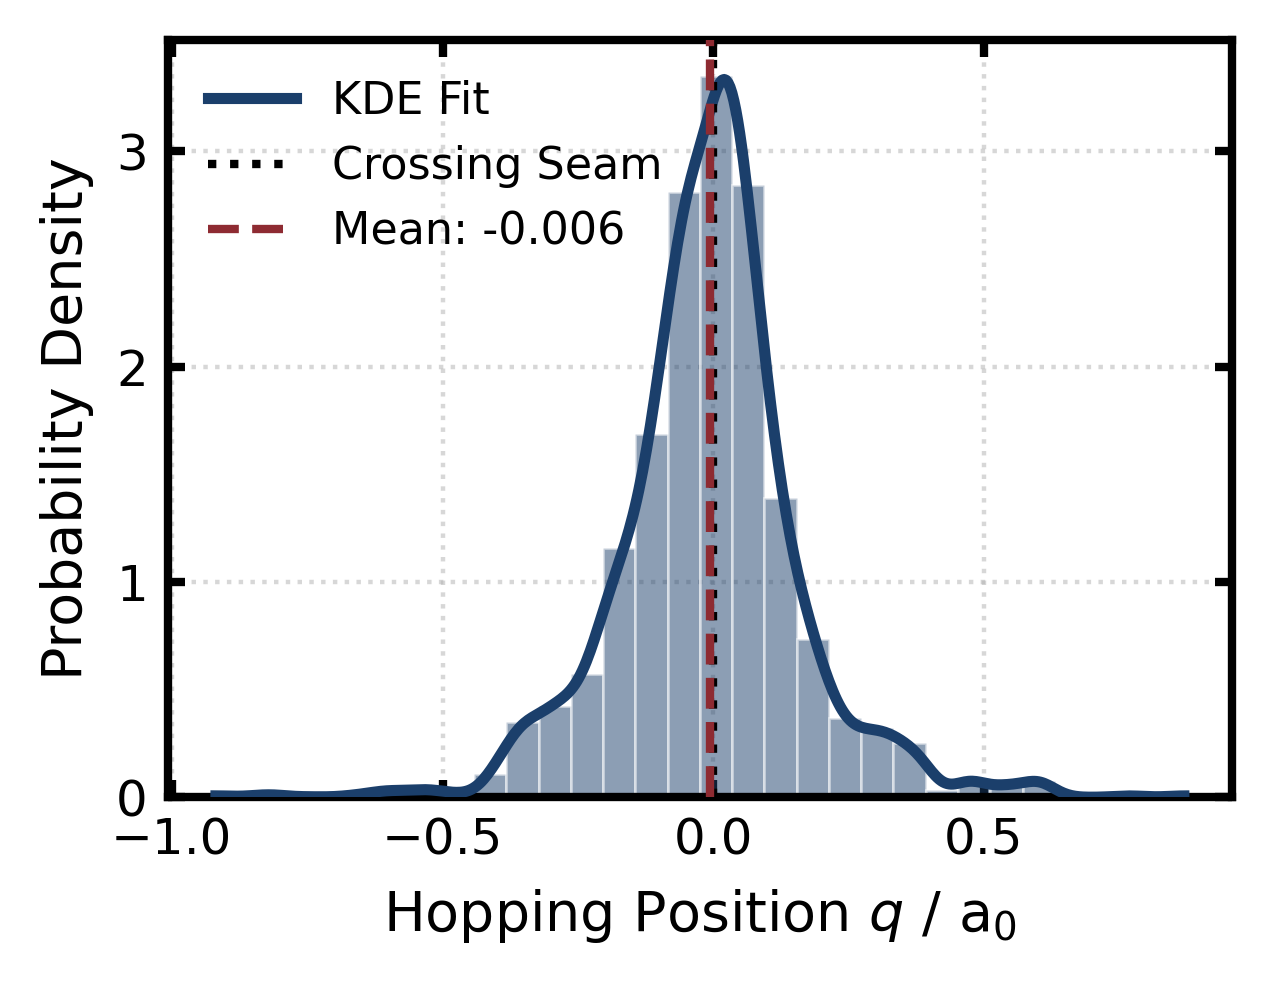

In [13]:
def plot_hopping_geometry_dist_publish(q_hops):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Standard single-column width (3.4 x 2.6)
    fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=400)

    # ==========================================
    # 2. PLOTTING THE DISTRIBUTION
    # ==========================================
    # The elegant, modern histogram in Winter Pine
    ax.hist(
        q_hops,
        bins=30,
        density=True,
        color=oxford_blue,
        edgecolor='white',    # Sharp white borders
        linewidth=0.5,
        alpha=0.5,            # Soft transparency
        zorder=2
    )

    # The smooth KDE envelope
    kde = gaussian_kde(q_hops)
    x_grid = np.linspace(min(q_hops), max(q_hops), 500)
    ax.plot(x_grid, kde(x_grid), color=oxford_blue, linewidth=2, zorder=3, label="KDE Fit")

    # The Theoretical Crossing Seam (Black dotted)
    ax.axvline(0.0, color='black', linestyle=':', linewidth=1.5, zorder=4,
               label='Crossing Seam')

    # The Calculated Mean Marker (Cranberry for high contrast)
    mean_q = np.mean(q_hops)
    ax.axvline(mean_q, color=cranberry, linestyle='--', linewidth=1.5, zorder=5,
               label=rf'Mean: {mean_q:.3f}')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Journal-standard unit formatting
    ax.set_xlabel(r"Hopping Position $q$ / a$_0$", fontweight='medium')
    ax.set_ylabel("Probability Density", fontweight='medium')

    # Grid and Ticks
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Clean, borderless legend with slightly smaller font to fit the markers
    ax.legend(loc='upper left', frameon=False, fontsize=8)

    plt.tight_layout()
    plt.savefig("Hopping_Geometry_Distribution.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_hopping_geometry_dist_publish(q_hops)

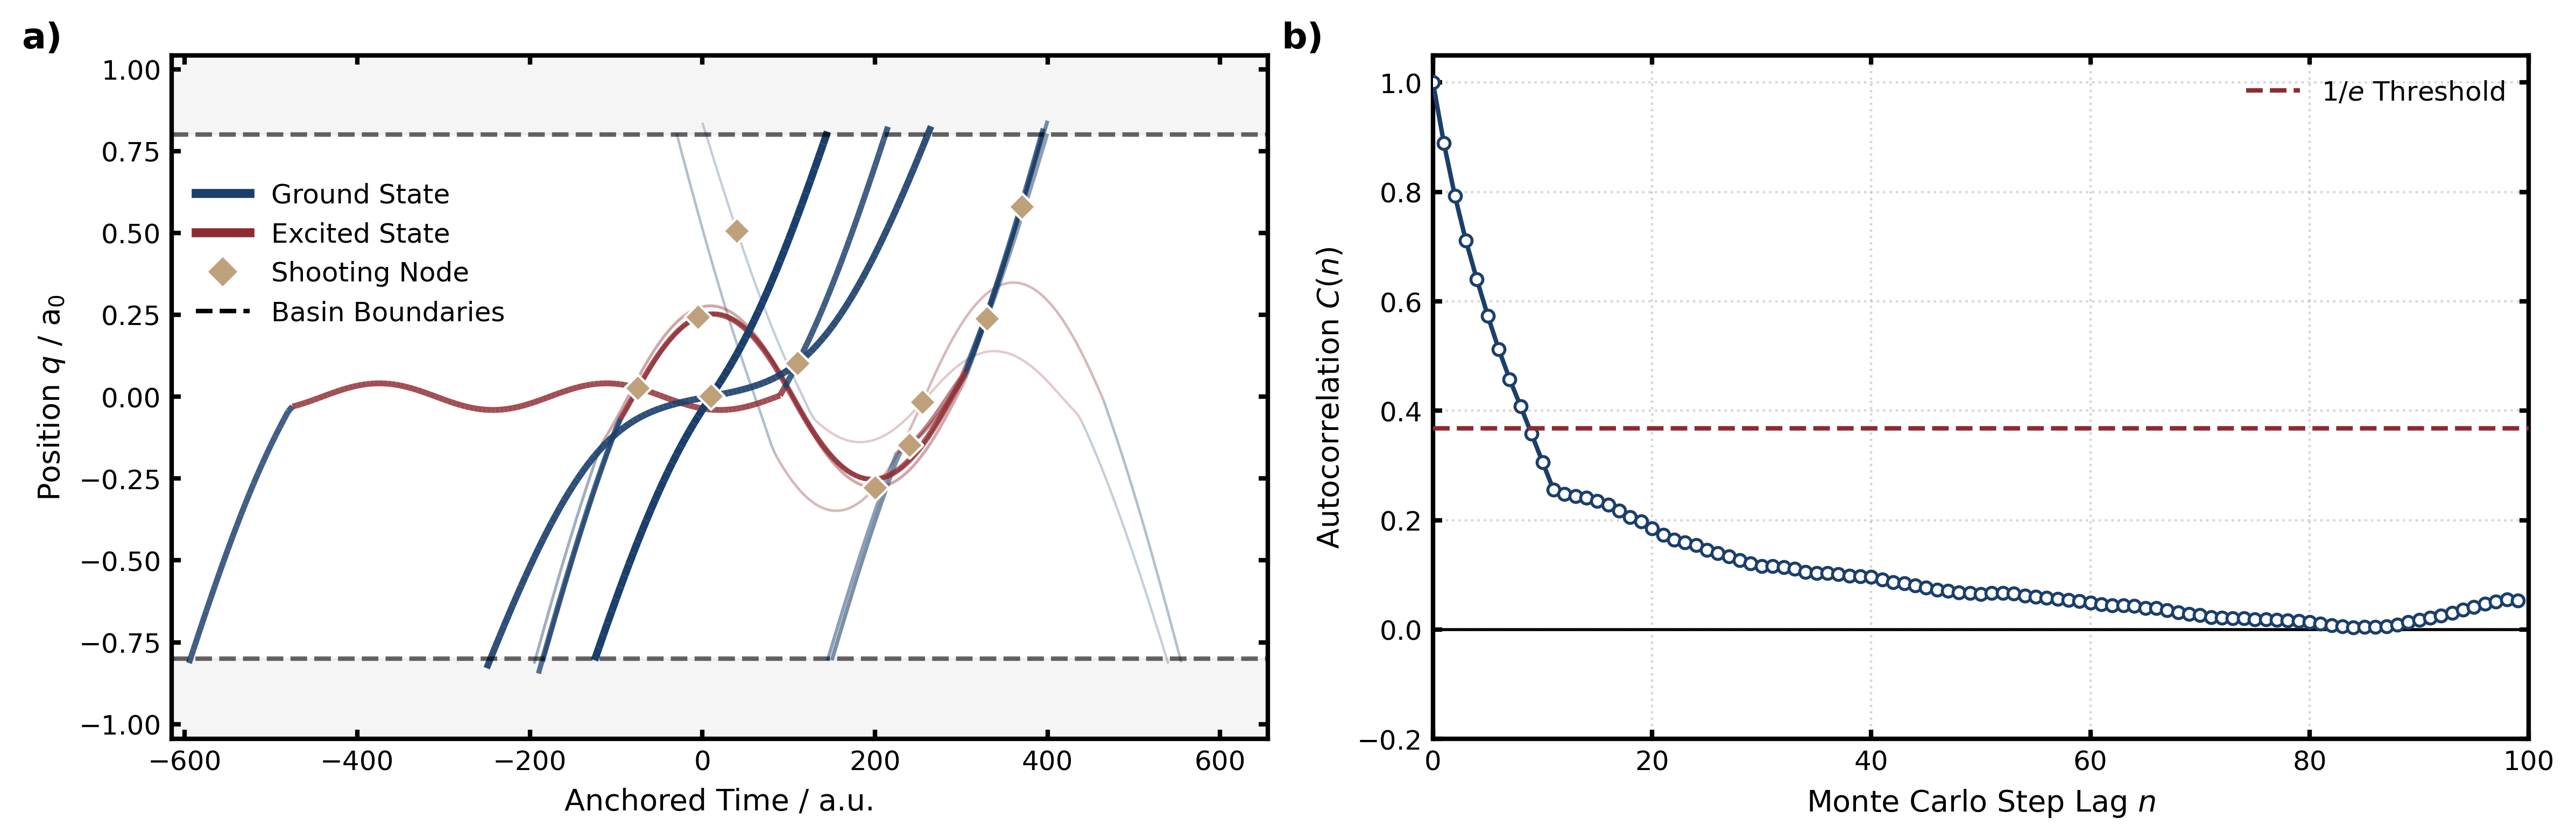

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def visualize_tps_lineage_publish(consecutive_ensemble, dt):
    """
    Plots a time-anchored TPS tree with progressive bolding and labeling,
    styled for double-column journal publication.
    """
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Double-column width (7.2), slightly taller (4.0) to give branches room to breathe
    fig, axes = plt.subplots(1,2, figsize=(12.0, 4.0), dpi=400)
    
    # Convert hex colors to RGB tuples for LineCollection
    base_0 = mcolors.to_rgb(oxford_blue)
    base_1 = mcolors.to_rgb(cranberry)

    # ==========================================
    # 2. TIME ANCHORING LOGIC (Untouched)
    # ==========================================
    time_shifts = [0.0] * len(consecutive_ensemble)
    q_min, q_max = float('inf'), float('-inf')
    
    for i in range(1, len(consecutive_ensemble)):
        grid_curr = [s for s in consecutive_ensemble[i] if s.is_grid]
        grid_prev = [s for s in consecutive_ensemble[i-1] if s.is_grid]
        shoot_idx_curr = next((idx for idx, s in enumerate(grid_curr) if getattr(s, 'shooting', False)), None)
        
        if shoot_idx_curr is not None:
            q_shoot = grid_curr[shoot_idx_curr].positions
            distances = [abs(s.positions - q_shoot) for s in grid_prev]
            shoot_idx_prev = np.argmin(distances)
            time_shifts[i] = (shoot_idx_prev * dt + time_shifts[i-1]) - (shoot_idx_curr * dt)
        else:
            time_shifts[i] = time_shifts[i-1]

    # ==========================================
    # 3. PLOTTING THE LINEAGE TREE
    # ==========================================
    ax1 = axes[0]
    max_absolute_time = 0
    N = len(consecutive_ensemble)
    
    for i, traj in enumerate(consecutive_ensemble):
        grid_traj = [s for s in traj if s.is_grid]
        times = np.arange(len(grid_traj)) * dt + time_shifts[i]
        positions = [s.positions for s in grid_traj]
        states = [s.active_state for s in grid_traj]
        
        q_min, q_max = min(q_min, min(positions)), max(q_max, max(positions))
        max_absolute_time = max(max_absolute_time, max(times))

        # Scale down linewidths for print resolution (0.8 to 2.5)
        lw = 0.8 + 1.7 * (i / (N - 1 if N > 1 else 1))**1.5 
        alpha = 0.25 + 0.75 * (i / (N - 1 if N > 1 else 1))
        
        points = np.array([times, positions]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        colors = [base_0 if state == 0 else base_1 for state in states[:-1]]
        
        lc = LineCollection(segments, colors=colors, alpha=alpha, linewidths=lw)
        ax1.add_collection(lc)
        
        # Shooting nodes: scaled down to size 40, colored golden
        for j, snap in enumerate(grid_traj):
            if getattr(snap, 'shooting', False) is True:
                ax1.scatter(times[j], positions[j], color=golden, 
                           edgecolor='white', marker='D', s=40, zorder=10, linewidth=0.8)

    # ==========================================
    # 4. BASIN BOUNDARIES & AESTHETICS
    # ==========================================
    ax1.axhline(y=-0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    ax1.axhline(y=0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Faint shading for the stable basins
    ax1.fill_between([min(time_shifts)-50, max_absolute_time+150], -2.5, -0.8, color='gray', alpha=0.08, zorder=0)
    ax1.fill_between([min(time_shifts)-50, max_absolute_time+150], 0.8, 2.5, color='gray', alpha=0.08, zorder=0)
    
    # Journal-standard axis labels
    ax1.set_xlabel("Anchored Time / a.u.", fontweight='medium')
    ax1.set_ylabel("Position $q$ / a$_0$", fontweight='medium')
    
    # Custom Legend
    legend_elements = [
        Line2D([0], [0], color=oxford_blue, lw=3, label='Ground State'),
        Line2D([0], [0], color=cranberry, lw=3, label='Excited State'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor=golden, 
               markeredgecolor='white', markersize=8, label='Shooting Node'),
        Line2D([0], [0], color='black', ls='--', lw=1.5, label='Basin Boundaries')
    ]
    ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor = (0.0,0.85), frameon=False, fontsize=9)
    
    # Perfect framing
    ax1.set_xlim(min(time_shifts) - 20, max_absolute_time + 100)
    ax1.set_ylim(q_min - 0.2, q_max + 0.2)
    
    # Thick boundaries and inward ticks
    ax1.tick_params(direction='in', top=True, right=True)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)

    ax2 = axes[1]

    # ==========================================
    # 2. PLOTTING THE AUTOCORRELATION
    # ==========================================
    # Main decay line (Winter Pine)
    # Adding white marker faces for that crisp, premium journal look
    ax2.plot(range(100), auto_correlation, color=oxford_blue, 
            linewidth=1.5, linestyle='-', marker='o', markersize=4, 
            markerfacecolor='white', markeredgewidth=1.0, zorder=3)
    
    # y=0 baseline
    ax2.axhline(0, color='black', linewidth=1.0, zorder=2)
    
    # 1/e Threshold (Cranberry)
    ax2.axhline(np.exp(-1), color=cranberry, linestyle='--', linewidth=1.5, zorder=4, 
               label=r'$1/e$ Threshold')

    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    ax2.set_xlabel("Monte Carlo Step Lag $n$", fontweight='medium')
    ax2.set_ylabel(r"Autocorrelation $C(n)$", fontweight='medium')

    # Grid and Ticks
    ax2.tick_params(direction='in', top=True, right=True)
    ax2.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Thicken axes
    for spine in ax2.spines.values():
        spine.set_linewidth(1.5)

    # Frame the data perfectly
    ax2.set_xlim(0, 100) # max_mc_lag
    # Standard limits for normalized ACF to show the peak at 1.0 and a bit of negative space
    ax2.set_ylim(-0.2, 1.05) 

    # Clean, borderless legend
    ax2.legend(loc='upper right', frameon=False, fontsize=9)

    ax1.text(-0.1, 1.05, 'a)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax2.text(-0.1, 1.05, 'b)', transform=ax2.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    

    plt.tight_layout()
    plt.savefig("TPS_Lineage_Tree.png", dpi=400, bbox_inches='tight')
    plt.show()


# Run it:
unique_succession = []
for traj in trimmed_tps_ensemble:
    if not unique_succession or traj is not unique_succession[-1]:
        unique_succession.append(traj)

unique_succession = unique_succession[610:620]

visualize_tps_lineage_publish(unique_succession, dt=dt, )